In [1]:
import numpy as np
from heat_experiment_2d import HeatExperiment2D
from random_shape import generate_smooth_blobs, generate_line
import matplotlib.pyplot as plt
%matplotlib widget

In [2]:
def fake_response_function(terminal_time, timestep):
    x = np.linspace(0, 0.5)
    y1 = 2*(1/(1+np.exp(-16*x))-0.5)
    x = np.linspace(-0.5, 0)
    y2 = -2*(1/(1+np.exp(-16*(x)))-0.5)
    y = np.append(y1, y2)
    x = np.linspace(0, 1, 100)
    
    t = np.arange(0, terminal_time, timestep)/terminal_time
    yt = np.interp(t, x, y)
    return yt

In [3]:
width, height = 100, 100
# image_blobs = generate_smooth_blobs(width, height)
# image_blobs.save("random_shape.png")
image_vein = generate_line(width, height)
# image_vein.save("random_line.png")

In [4]:
diff_iron = 23e-6
diff_steel = 11.72e-6
diff_silicon = 88e-6
diff_tissue = 17e-6
diff_coefficients = [diff_steel, diff_silicon, diff_iron] # order matters

In [5]:
vein_mask = ~np.array(image_vein, dtype=bool)
vein_fullness = 1
vein_mask = vein_fullness*vein_mask 

In [6]:
blob_masks = []
for coeff in diff_coefficients:
    image_blobs = generate_smooth_blobs(width, height)
    blob_mask = ~np.array(image_blobs, dtype=bool)
    blob_mask = coeff*blob_mask
    blob_masks.append(blob_mask)

In [7]:
terminal = 80
timestep = 0.1
node_x = width 
node_y = height #every pixel gets a node
diffusion_coefficient_matrix = np.zeros((node_x, node_y))
# vein
diffusion_coefficient_matrix = np.where(diffusion_coefficient_matrix == 0, vein_mask*diff_iron, diffusion_coefficient_matrix)
# blobs
for mask in blob_masks:
    diffusion_coefficient_matrix = np.where(diffusion_coefficient_matrix == 0, mask, diffusion_coefficient_matrix)
# space in between
diffusion_coefficient_matrix = np.where(diffusion_coefficient_matrix == 0, diff_tissue, diffusion_coefficient_matrix)

In [8]:
vein_values = fake_response_function(terminal, timestep)
vein_values.max()

np.float64(0.9993292997390673)

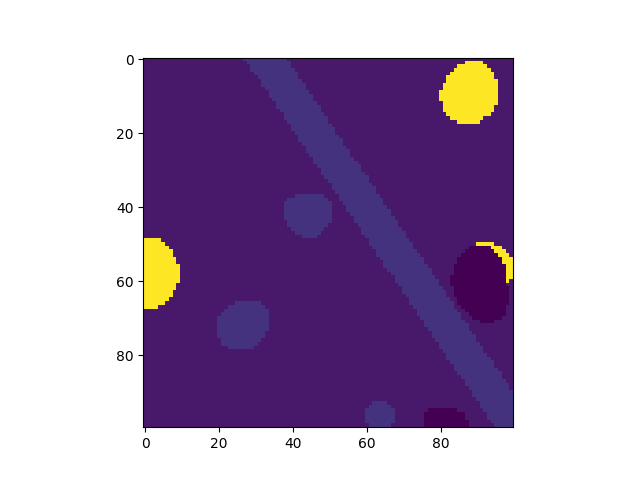

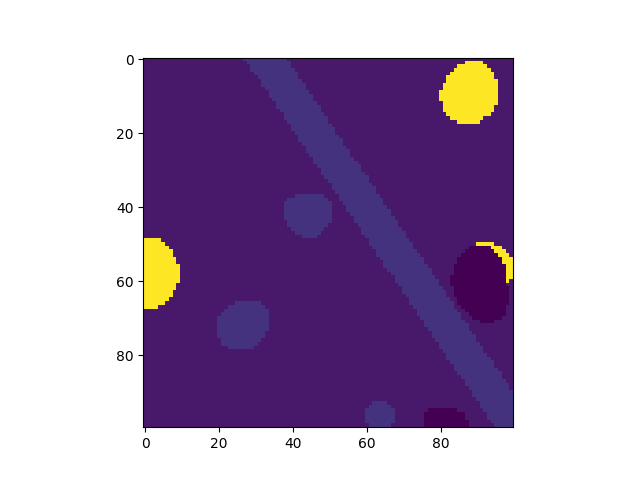

In [9]:
fig, ax = plt.subplots()
ax.imshow(diffusion_coefficient_matrix)
fig.show()

In [10]:
exp1 = HeatExperiment2D(terminal_time=terminal, timestep=timestep, vein_function_values = vein_values,
                        length_x=0.1, length_y=0.1, boundary_value=0, x_nodes=node_x, y_nodes=node_y,
                        vein_masks = [vein_mask], coefficient_matrix=diffusion_coefficient_matrix, initial_value=0, cmap='cmr.arctic')
exp1.run_calculation()

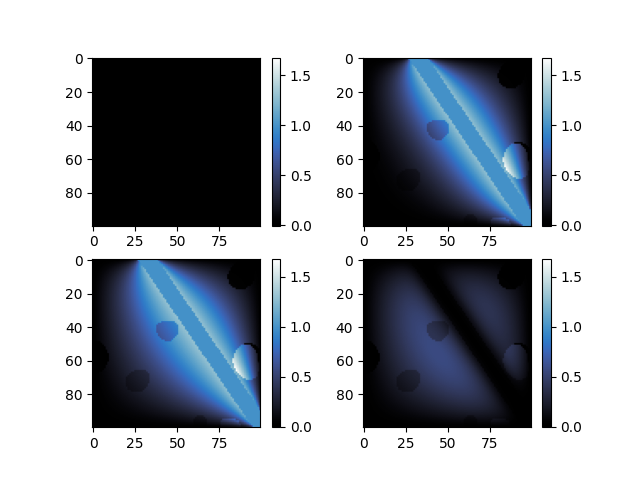

In [11]:
exp1.visualize_snapshots()

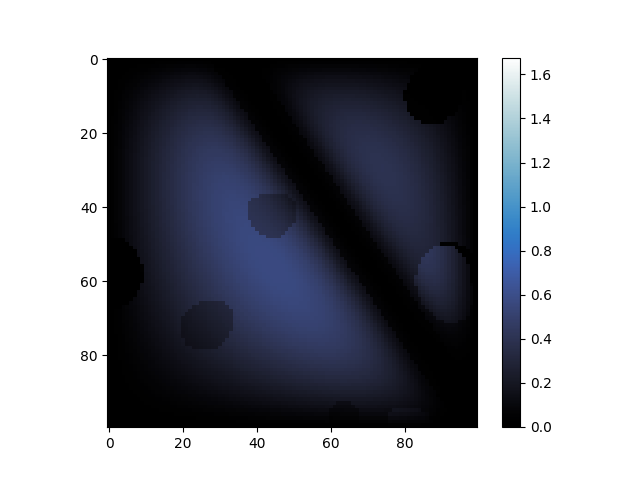

In [12]:
exp1.visualize_animated(save=True, display=False)